In [1]:
import sys
import os
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx
import pytorch_lightning as pl

sys.path.append(os.path.abspath('../src'))

from loading.LightningGraphLoader import load_datasets
from models.MyModel import MyModel
from loading.DatasetInfo import DatasetInfo

/Users/williserdman/Documents/school/Koyuturk/ms_thesis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the Cora dataset
datasets = load_datasets(['Cora', "squirrel"])
cora = datasets['Cora']
squirrel = datasets["squirrel"]
ds_name = "Squirrel"

# Get the underlying PyG Data object
# cora.data is a LightningNodeData object. We can check if it holds the data.
# Based on common usage, we can get the dataset from a dataloader or attributes.
# Let's try to access the original data if possible.
# LightningNodeData(data, ...) -> stores data in self.data?
# Let's assume we can get it via cora.data for now, or inspecting the dataloader.
# Actually, the quickest way to get the data object is to use the same private loading function or just look at what LightningNodeData provides.
# Since we are in the notebook, we can inspect. But for automation, I will assume we can access it via a loader.
# cora.data.train_dataloader().dataset might be a subset or the full dataset depending on implementation.
# But 'loader="full"' suggests full batch.
dl = squirrel.data.train_dataloader()
graph_data = dl.dataset[0]
# graph_data should be the Data object provided to LightningNodeData
print(f"Loaded graph with {len(graph_data.x[0])} nodes and {len(graph_data.edge_index[1])} edges.")

Loaded graph with 2089 nodes and 65718 edges.


/Users/williserdman/Documents/school/Koyuturk/ms_thesis/src/loading/LightningGraphLoader.py:237: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out[n] = LightningGraph(t, nf, nc, torch.tensor(class_weights))


In [3]:
# Path to the best checkpoint for Cora (version 16)
checkpoint_path = "../../optuna_logs/best_params/version_0/checkpoints/epoch=114-step=115.ckpt" # Cora
checkpoint_path = "../lightning_logs/version_0/checkpoints/epoch=1742-step=1743.ckpt" # squirrel

# Load the model
try:
    model = MyModel.load_from_checkpoint(checkpoint_path)
    model.eval()
    print("Model loaded successfully")
except Exception as e:
    print(f"Failed to load model: {e}")
    # Fallback or debugging hints
    print("Ensure that hparams.yaml contains valid ds_info and that the class is importable.")

Model loaded successfully


/Users/williserdman/Documents/school/Koyuturk/ms_thesis/src/models/MyModel.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.cse = nn.CrossEntropyLoss(torch.tensor(ds_info.class_weights))


In [4]:
# Run the model on the full graph
with torch.no_grad():
    # Model expects 'data' object with .x and .edge_index
    logits, _ = model(graph_data)
    probs = torch.softmax(logits, dim=1)
    predictions = logits.argmax(dim=1)

# Calculate accuracy
# Assuming y is the ground truth labels
ground_truth = graph_data.y
# accuracy per node
correct_predictions = (predictions == ground_truth)
accuracy_per_node = correct_predictions.float()

print(f"Overall Accuracy: {accuracy_per_node.mean().item():.4f}")

# You can inspect specific nodes
print(f"First 10 nodes correct? {correct_predictions[:10].tolist()}")

train_mask = graph_data.train_mask
val_mask = graph_data.val_mask
test_mask = graph_data.test_mask


# Calculate accuracy per split
train_accuracy = accuracy_per_node[train_mask].mean().item()
val_accuracy = accuracy_per_node[val_mask].mean().item()
test_accuracy = accuracy_per_node[test_mask].mean().item()

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Val Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Overall Accuracy: 0.6442
First 10 nodes correct? [True, True, True, False, False, True, True, False, True, True]
Train Accuracy: 0.9815
Val Accuracy: 0.3214
Test Accuracy: 0.3318


Computing layout (this may take a moment)...
Drawing graph...


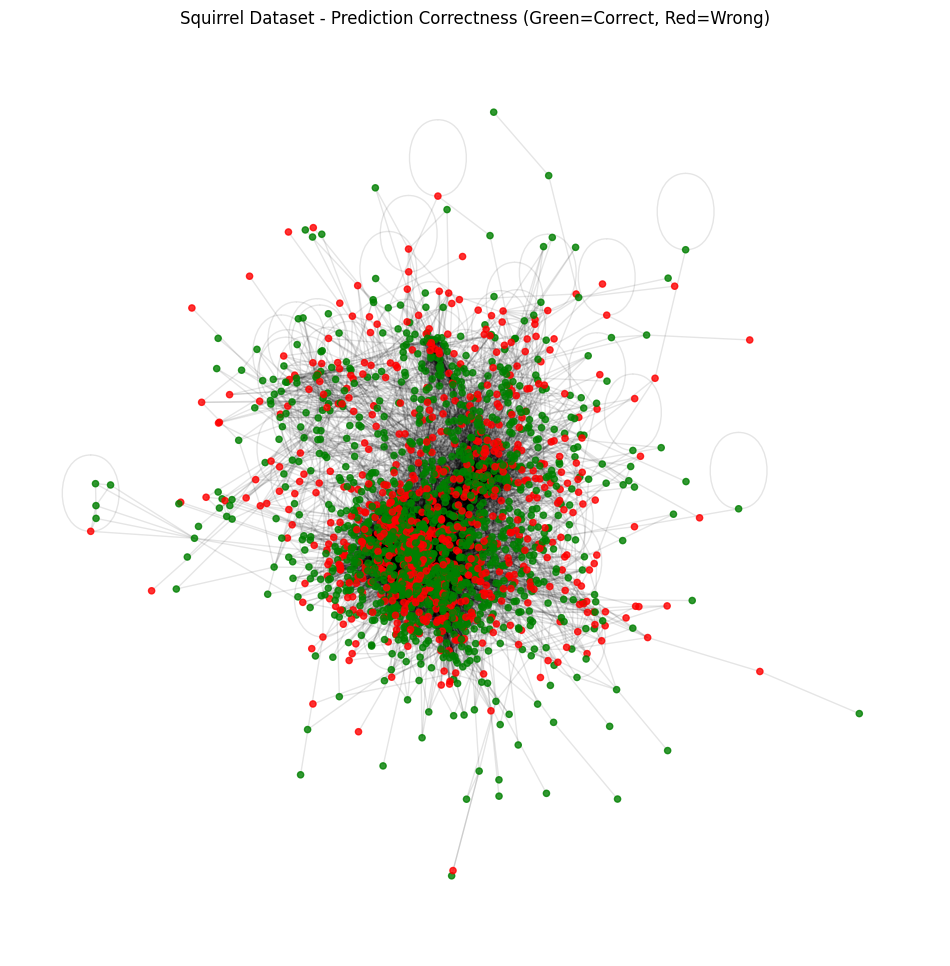

In [5]:
# Visualization
# Convert PyG data to NetworkX graph
G = to_networkx(graph_data, to_undirected=True)

# Define node colors based on correctness
# Green for correct, Red for incorrect
node_colors = ['green' if correct else 'red' for correct in correct_predictions.tolist()]

plt.figure(figsize=(12, 12))
print("Computing layout (this may take a moment)...")
# Use spring layout
pos = nx.spring_layout(G, k=0.1, iterations=50) # Reduced iterations for speed

node_edge_colors = []
for i in range(len(G.nodes)):
    if train_mask[i]:
        node_edge_colors.append('black')
    else:
        node_edge_colors.append('blue')

print("Drawing graph...")
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_colors, alpha=0.8,) # edgecolors=node_edge_colors)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title(f"{ds_name} Dataset - Prediction Correctness (Green=Correct, Red=Wrong)")
plt.axis('off')
plt.show()

/var/folders/60/wj5t6qgs4mg17szk59gn23300000gn/T/ipykernel_20997/3948254421.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', num_classes)


Drawing graph with class label colors...


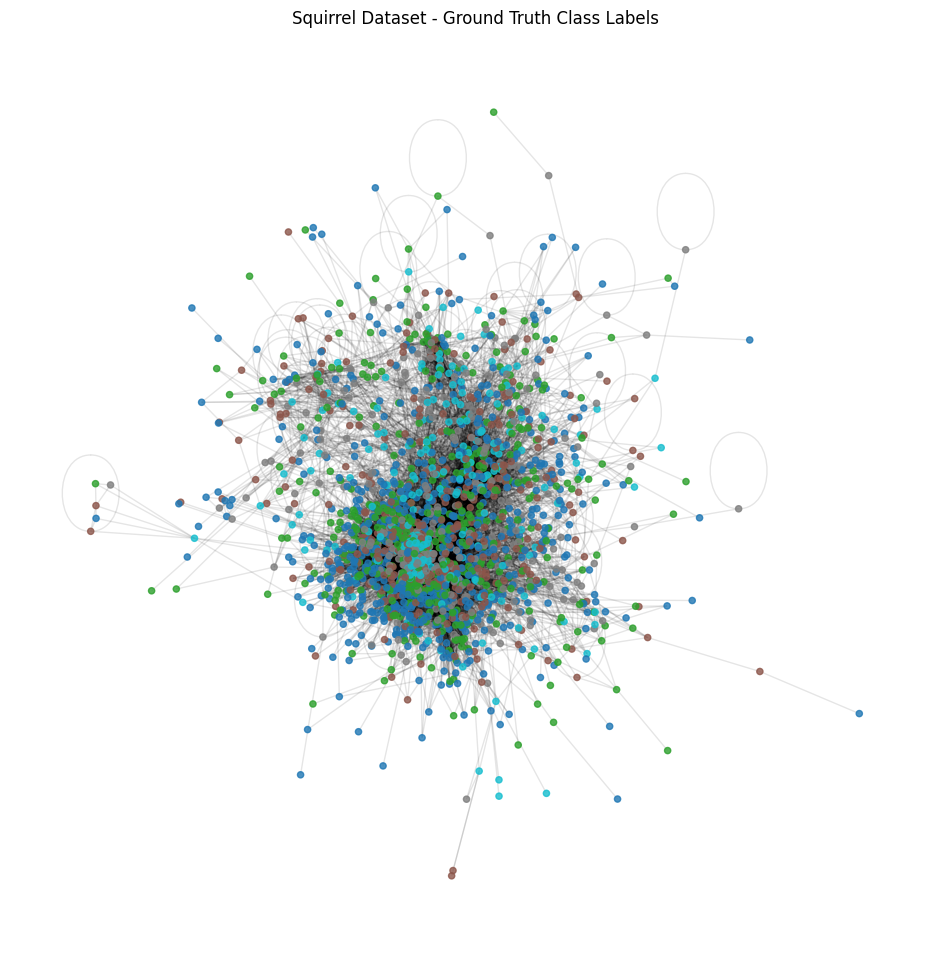

In [6]:
import numpy as np

# Visualize the Cora graph with node colors based on ground truth class labels

# Assign a color to each class label
import matplotlib.cm as cm

num_classes = len(torch.unique(ground_truth))
cmap = cm.get_cmap('tab10', num_classes)
class_colors = [cmap(label.item()) for label in ground_truth]

plt.figure(figsize=(12, 12))
print("Drawing graph with class label colors...")
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=class_colors, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)

plt.title(f"{ds_name} Dataset - Ground Truth Class Labels")
plt.axis('off')
plt.show()

Original graph: 2223 nodes, 47138 edges
Subgraph (Training and Validation Nodes): 1285 nodes, 16675 edges


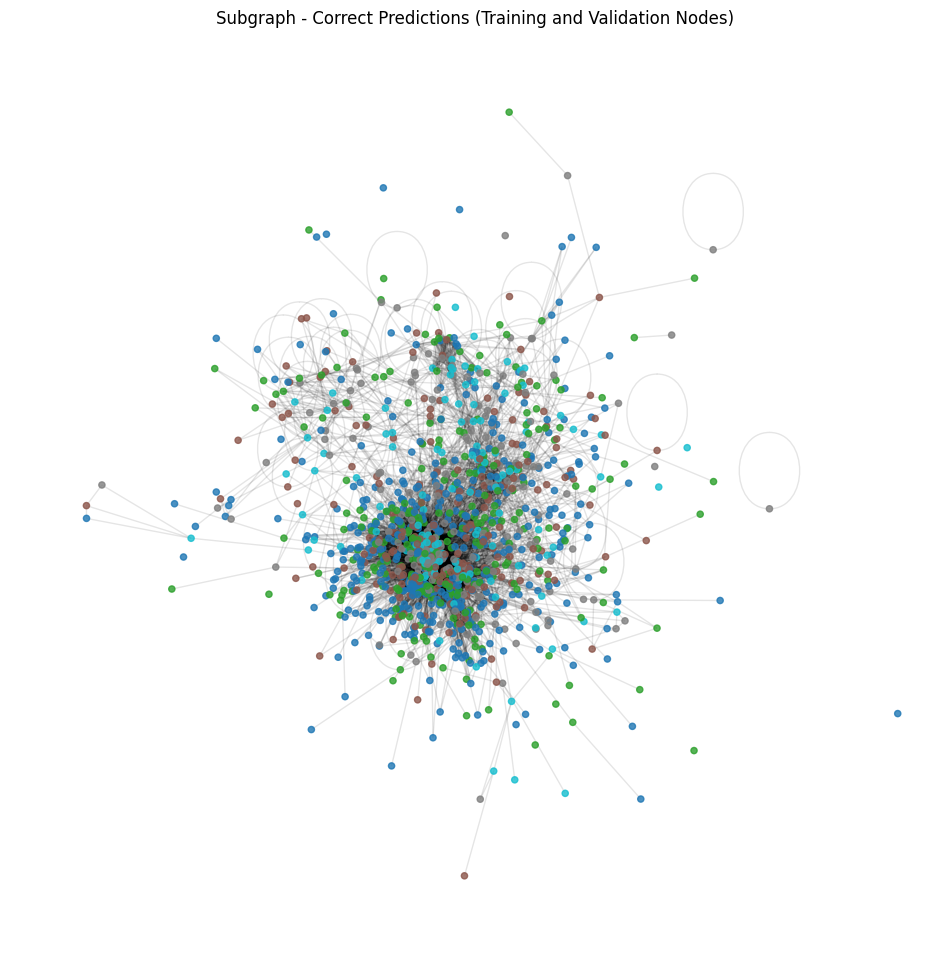

In [7]:
# Flag to filter for training nodes only
TRAINING_NODES = False
TRAIN_AND_VAL = True

# Create a mask for nodes to include
if TRAINING_NODES:
    # Intersection: Correctly predicted AND in training set
    subset_mask = correct_predictions & train_mask
    title_suffix = " (Training Nodes Only)"
elif TRAIN_AND_VAL:
    subset_mask = correct_predictions & (train_mask | val_mask)
    title_suffix = " (Training and Validation Nodes)"
else:
    # Just correctly predicted nodes
    subset_mask = correct_predictions
    title_suffix = " (All Correct Nodes)"

subset_indices = torch.where(subset_mask)[0].tolist()
subgraph = G.subgraph(subset_indices).copy()

print(f"Original graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Subgraph{title_suffix}: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

# Visualize the subgraph
plt.figure(figsize=(12, 12))
pos_subgraph = {node: pos[node] for node in subgraph.nodes()}
# Use the same colors as the original graph (by node index)
subgraph_colors = [class_colors[node] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_subgraph, node_size=20, node_color=subgraph_colors, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos_subgraph, alpha=0.1)

plt.title(f"Subgraph - Correct Predictions{title_suffix}")
plt.axis('off')
plt.show()

Subgraph (Training and Validation Nodes): 495 nodes, 2093 edges


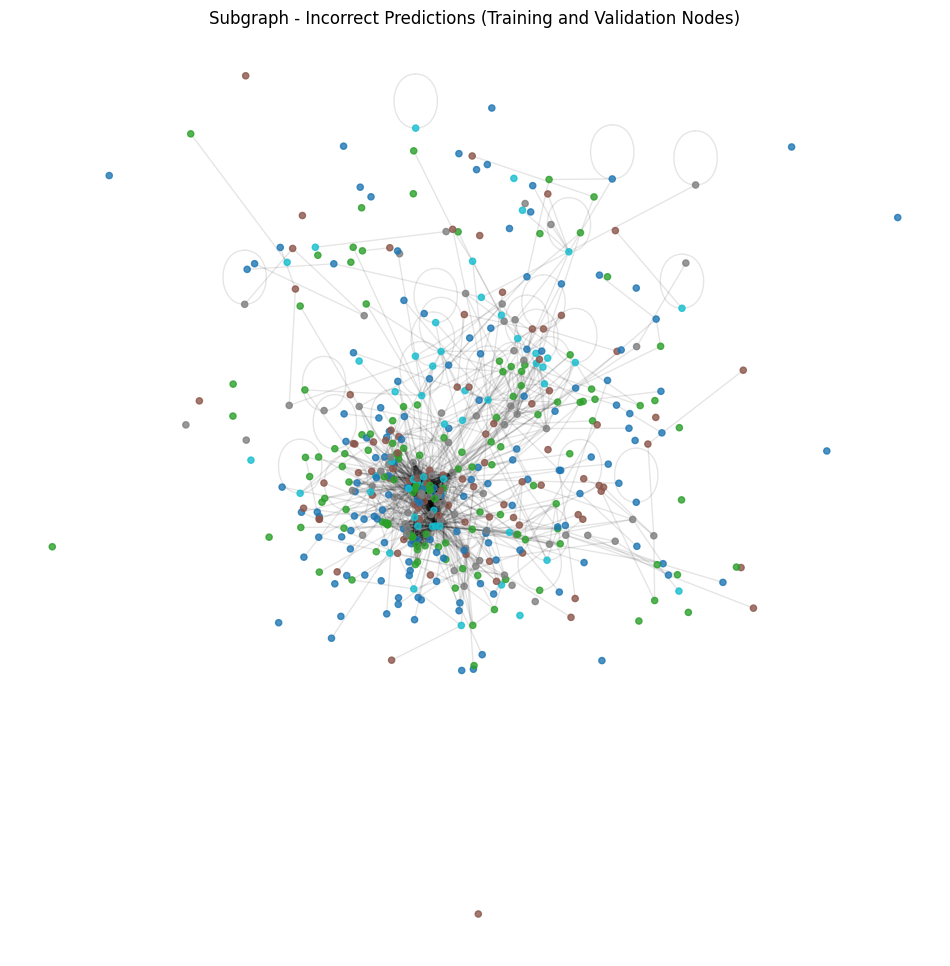

In [8]:
# Flag to filter for training nodes only
TRAINING_NODES = False
TRAIN_AND_VAL = True

# Create a mask for nodes to include
if TRAINING_NODES:
    # Intersection: Correctly predicted AND in training set
    subset_mask = (correct_predictions==0) & train_mask
    title_suffix = " (Training Nodes Only)"
elif TRAIN_AND_VAL:
    subset_mask = (correct_predictions==0) & (train_mask | val_mask)
    title_suffix = " (Training and Validation Nodes)"
else:
    # Just correctly predicted nodes
    subset_mask = correct_predictions
    title_suffix = " (All Correct Nodes)"

subset_indices = torch.where(subset_mask)[0].tolist()
subgraph = G.subgraph(subset_indices).copy()

print(f"Subgraph{title_suffix}: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

# Visualize the subgraph
plt.figure(figsize=(12, 12))
pos_subgraph = {node: pos[node] for node in subgraph.nodes()}
# Use the same colors as the original graph (by node index)
subgraph_colors = [class_colors[node] for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_subgraph, node_size=20, node_color=subgraph_colors, alpha=0.8)
nx.draw_networkx_edges(subgraph, pos_subgraph, alpha=0.1)

plt.title(f"Subgraph - Incorrect Predictions{title_suffix}")
plt.axis('off')
plt.show()

Edges: Correct-Correct: 19930, Incorrect-Incorrect: 5733, Mixed: 21475


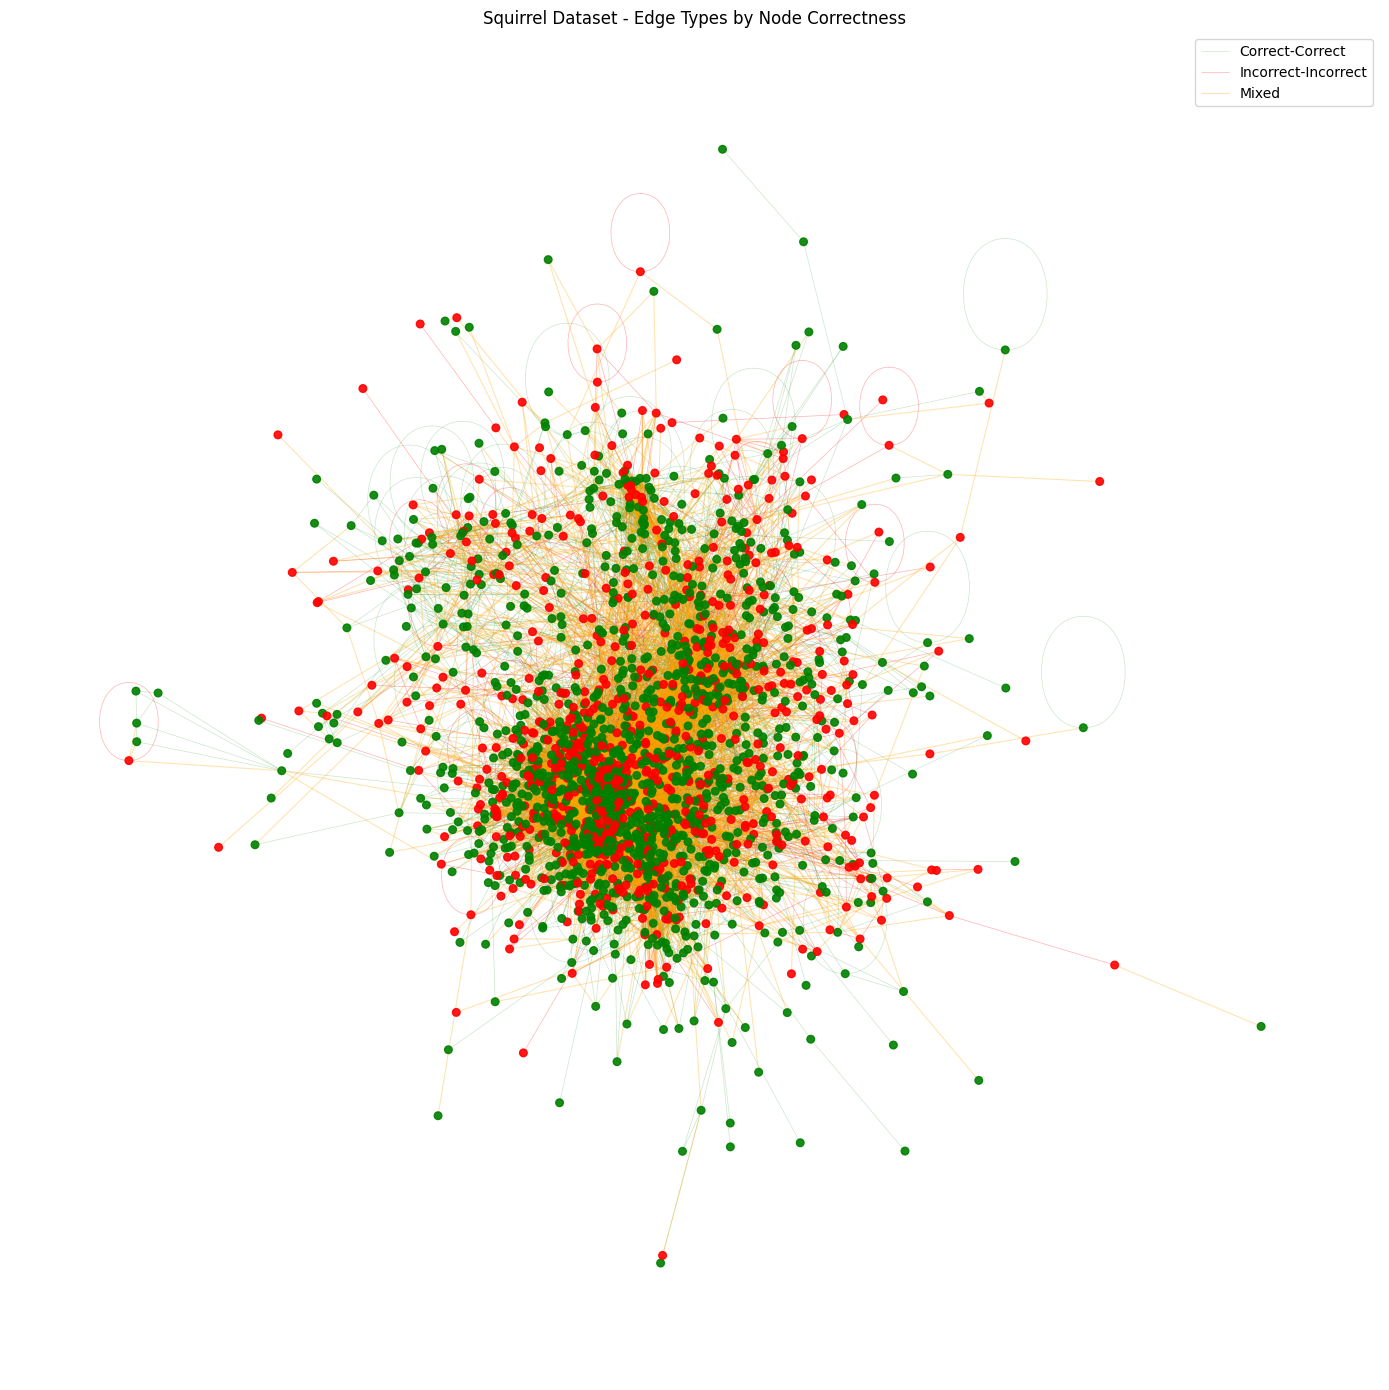


Edge Distribution:
Correct-Correct: 42.28%
Incorrect-Incorrect: 12.16%
Mixed (boundary): 45.56%


In [9]:
# Create a graph with edges colored based on whether they connect correct/incorrect nodes
fig, ax = plt.subplots(figsize=(14, 14))

# Separate edges into three categories
correct_to_correct = []
incorrect_to_incorrect = []
mixed_edges = []

for edge in G.edges():
    node1, node2 = edge
    node1_correct = correct_predictions[node1].item()
    node2_correct = correct_predictions[node2].item()
    
    if node1_correct and node2_correct:
        correct_to_correct.append(edge)
    elif not node1_correct and not node2_correct:
        incorrect_to_incorrect.append(edge)
    else:
        mixed_edges.append(edge)

print(f"Edges: Correct-Correct: {len(correct_to_correct)}, "
      f"Incorrect-Incorrect: {len(incorrect_to_incorrect)}, "
      f"Mixed: {len(mixed_edges)}")

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=node_colors, alpha=0.9)

# Draw edges with different colors
nx.draw_networkx_edges(G, pos, edgelist=correct_to_correct, 
                       edge_color='green', alpha=0.2, width=0.5, label='Correct-Correct')
nx.draw_networkx_edges(G, pos, edgelist=incorrect_to_incorrect, 
                       edge_color='red', alpha=0.3, width=0.5, label='Incorrect-Incorrect')
nx.draw_networkx_edges(G, pos, edgelist=mixed_edges, 
                       edge_color='orange', alpha=0.3, width=0.8, label='Mixed')

plt.title(f"{ds_name} Dataset - Edge Types by Node Correctness")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

# Print statistics
total_edges = G.number_of_edges()
print(f"\nEdge Distribution:")
print(f"Correct-Correct: {len(correct_to_correct)/total_edges:.2%}")
print(f"Incorrect-Incorrect: {len(incorrect_to_incorrect)/total_edges:.2%}")
print(f"Mixed (boundary): {len(mixed_edges)/total_edges:.2%}")

In [10]:
# Print the test mask
print("Test mask:")
print(test_mask.tolist())

# Get indices of nodes in the test set that were correctly predicted
test_correct_indices = torch.where(test_mask & correct_predictions)[0].tolist()
print(f"\nIndices of correctly predicted nodes in test set:")
print(test_correct_indices)
print(f"Number of correct predictions in test set: {len(test_correct_indices)}")

Test mask:
[False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, True, False, True, False, False, False, True, True, False, True, False, True, False, False, True, False, False, False, True, True, False, True, False, False, False, False, True, False, True, True, False, False, False, True, False, False, True, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, True, False, False, True, True, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, False, True, False, False, False, True, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, True, Fals

In [12]:
ptm = [False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, True, False, True, False, False, False, True, True, False, True, False, True, False, False, True, False, False, False, True, True, False, True, False, False, False, False, True, False, True, True, False, False, False, True, False, False, True, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, True, False, False, True, True, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, False, True, False, False, False, True, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, False, True, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, True, False, False, True, False, False, False, False, True, True, False, True, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, True, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, True, False, False, False, True, False, False, False, False, True, False, True, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, True, False, True, False, True, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, True, True, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, True, False, False, True, True, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, True, False, False, False, False, False, False, True, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, False, True, True, False, False, True, False, False, False, False, True, False, False, False, True, True, False, False, False, True, False, True, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, True, True, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, True, True, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, True, False, False, True, False, False, False, False, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, True, False, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, True, False, False, False, False, False, False, True, False, False, True, False, False, True, True, False, False, False, False, False, True, False, True, False, False, False, True, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, True, False, True, True, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, True, True, True, False, False, True, False, False, True, False, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, True, True, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, True, False, False, False, False, True, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, True, False, False, True, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, True, True, True, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, True, False, False, True, False, False, True, False, False, True, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, True, False, False, False, True, True, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, False, False, False, True, True, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, False, True, True, True, False, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, True, False, True, False, False, True, True, False, True, False, False, False, False, True, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, True, True, False, False, False, False, True, False, False, False, False, False, True, False, False, True, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, True, True, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, True, False, False, True, False, False, True, False, False, False, False, True, True, False, False, True, False, True, False, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, True, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, True, True, False, True, False, False, True, False, False, False, False, True, False, False, True, False, True, False, True, False, True, True, True, False, False, False, False, False, False, True, False, True, True, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, True, True, True, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False]
gctm = [False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, True, False, True, False, False, False, True, True, False, True, False, True, False, False, True, False, False, False, True, True, False, True, False, False, False, False, True, False, True, True, False, False, False, True, False, False, True, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, True, False, False, True, True, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, False, True, False, False, False, True, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, False, True, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, True, False, False, True, False, False, False, False, True, True, False, True, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, True, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, True, False, False, False, True, False, False, False, False, True, False, True, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, True, False, True, False, True, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, True, True, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, True, False, False, True, True, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, True, False, False, False, False, False, False, True, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, False, True, True, False, False, True, False, False, False, False, True, False, False, False, True, True, False, False, False, True, False, True, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, True, True, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, True, True, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, True, True, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, True, False, False, True, False, False, False, False, True, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, True, False, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, True, False, False, False, False, False, False, True, False, False, True, False, False, True, True, False, False, False, False, False, True, False, True, False, False, False, True, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, True, False, False, False, True, False, False, False, True, False, True, True, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, True, True, True, False, False, True, False, False, True, False, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, True, True, False, False, False, False, False, True, False, False, False, False, True, False, False, True, False, True, False, False, False, False, True, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, True, False, False, True, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, True, True, True, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, True, False, False, True, False, False, True, False, False, True, False, False, True, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, True, False, False, False, True, True, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, False, False, False, True, True, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, False, True, True, True, False, True, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, False, False, False, False, True, False, True, False, False, True, True, False, True, False, False, False, False, True, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, True, True, False, False, False, False, True, False, False, False, False, False, True, False, False, True, False, True, False, False, True, False, False, False, False, True, False, False, False, False, False, False, True, True, False, False, False, False, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, True, True, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, True, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, True, False, False, True, False, False, True, False, False, False, False, True, True, False, False, True, False, True, False, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, False, False, False, True, False, False, False, True, False, False, False, True, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, True, True, True, False, True, False, False, True, False, False, False, False, True, False, False, True, False, True, False, True, False, True, True, True, False, False, False, False, False, False, True, False, True, True, False, False, False, False, False, True, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, True, True, True, False, False, False, False, True, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, True, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, True, False]
ptm == gctm

True

In [14]:
pcn = [16, 18, 23, 34, 42, 44, 49, 52, 53, 64, 74, 79, 118, 122, 123, 145, 154, 166, 169, 179, 201, 214, 227, 241, 246, 249, 257, 267, 297, 305, 312, 325, 346, 376, 381, 383, 401, 412, 436, 446, 451, 453, 482, 493, 517, 527, 529, 536, 562, 569, 586, 598, 641, 658, 659, 681, 691, 692, 742, 756, 757, 760, 769, 776, 779, 781, 796, 807, 826, 856, 886, 914, 931, 964, 992, 993, 1000, 1010, 1031, 1058, 1107, 1115, 1120, 1161, 1174, 1214, 1218, 1220, 1224, 1281, 1298, 1307, 1314, 1319, 1322, 1337, 1355, 1380, 1388, 1402, 1432, 1452, 1465, 1494, 1512, 1532, 1553, 1581, 1583, 1615, 1653, 1663, 1679, 1687, 1696, 1731, 1746, 1753, 1768, 1769, 1793, 1822, 1846, 1861, 1879, 1880, 1902, 1944, 1973, 2006, 2016, 2021, 2035, 2044, 2057, 2071, 2083, 2084, 2087, 2100, 2102, 2104, 2122, 2165, 2171, 2173, 2209]
gcn = [16, 18, 22, 23, 25, 27, 30, 34, 37, 42, 44, 52, 53, 64, 78, 79, 82, 92, 123, 160, 166, 209, 214, 236, 254, 256, 257, 288, 294, 305, 312, 336, 346, 348, 379, 389, 401, 406, 412, 446, 451, 461, 482, 510, 517, 525, 527, 529, 536, 552, 553, 557, 562, 569, 578, 598, 625, 657, 658, 659, 681, 691, 692, 712, 727, 737, 742, 749, 756, 757, 769, 774, 776, 777, 779, 826, 833, 855, 856, 875, 879, 886, 887, 931, 937, 939, 956, 964, 992, 993, 1000, 1010, 1044, 1049, 1050, 1079, 1082, 1107, 1113, 1115, 1120, 1137, 1145, 1148, 1158, 1162, 1168, 1174, 1201, 1214, 1241, 1279, 1281, 1300, 1304, 1314, 1380, 1382, 1388, 1402, 1421, 1427, 1432, 1465, 1470, 1512, 1520, 1532, 1560, 1566, 1578, 1581, 1592, 1595, 1615, 1617, 1651, 1653, 1696, 1713, 1753, 1769, 1804, 1833, 1853, 1880, 1902, 1906, 1915, 1924, 1944, 1969, 1975, 2001, 2006, 2016, 2018, 2021, 2041, 2057, 2061, 2066, 2082, 2084, 2087, 2095, 2105, 2116, 2146, 2160, 2164, 2171, 2173, 2188, 2202, 2209, 2215]
together = list(set(pcn).union(set(gcn)))
len(together)

243

In [15]:
total_test_nodes = graph_data.test_mask.sum().item()
print(f"Total number of test nodes: {total_test_nodes}")

Total number of test nodes: 443


In [16]:
243/443

0.5485327313769752